# 1 — Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

# 2 — Load Data

In [14]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
train_df.head()

Train shape: (7000, 26)
Test shape : (1124, 25)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


# 3 — Data Types

In [15]:
print("=== Data Types ===")
print(train_df.dtypes)
print(f"\nNumerical columns : {train_df.select_dtypes(include='number').columns.tolist()}")
print(f"Categorical columns: {train_df.select_dtypes(include='object').columns.tolist()}")

=== Data Types ===
ID                            int64
mushroom_id                   int64
cap-shape                    object
cap-surface                  object
cap-color                    object
bruises                      object
number_of_bruises             int64
odor                         object
gill-attachment              object
gill-spacing                 object
gill-size                    object
gill-color                   object
stalk-shape                  object
stalk-root                   object
stalk-surface-above-ring     object
stalk-surface-below-ring     object
stalk-color-above-ring       object
stalk-color-below-ring       object
veil-type                    object
veil-color                   object
ring-number                 float64
ring-type                    object
spore-print-color            object
population                   object
habitat                      object
class                        object
dtype: object

Numerical columns : ['ID', 'mu

# 4 — Descriptive Statistics (Numerical Columns)

In [16]:
num_cols = train_df.select_dtypes(include='number').columns.tolist()
stats = train_df[num_cols].agg(['min', 'max', 'mean', 'median'])
print("=== Descriptive Statistics (Numerical Columns) ===")
stats

=== Descriptive Statistics (Numerical Columns) ===


,ID,mushroom_id,number_of_bruises,ring-number
min,1.0,0.000000,0.000000,1.000000
max,7000.0,8118.000000,24.000000,2.000000
mean,3500.5,3850.617714,5.459571,1.080988
median,3500.5,3755.500000,0.000000,1.000000


# 5 — Missing Values

In [17]:
print("=== Missing Values (Train) ===")
missing_train = train_df.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(missing_train if len(missing_train) else "No missing values found.")

print("\n=== Missing Values (Test) ===")
missing_test = test_df.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(missing_test if len(missing_test) else "No missing values found.")

# Numerical: fill with mean (fit on train, apply to both)
for col in train_df.select_dtypes(include='number').columns:
  if col in test_df.columns:
    mean_val = train_df[col].mean()
    train_df[col] = train_df[col].fillna(mean_val)
    test_df[col] = test_df[col].fillna(mean_val)

# Categorical: fill with mode (fit on train, apply to both)
for col in train_df.select_dtypes(include='object').columns:
  if col in test_df.columns:
    mode_val = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(mode_val)
    test_df[col] = test_df[col].fillna(mode_val)

print("\nMissing after imputation — train:", train_df.isnull().sum().sum())
print("Missing after imputation — test :", test_df.isnull().sum().sum())

=== Missing Values (Train) ===
odor           3236
stalk-root      192
ring-number      36
ring-type        36
dtype: int64

=== Missing Values (Test) ===
odor    292
dtype: int64

Missing after imputation — train: 0
Missing after imputation — test : 0


# 6 — Duplicates

In [18]:
dupes = train_df.duplicated().sum()
print(f"=== Duplicates ===")
print(f"Duplicate rows found: {dupes}")

if dupes > 0:
  train_df.drop_duplicates(inplace=True)
  print(f"Duplicates dropped. New shape: {train_df.shape}")
else:
  print("No duplicates — nothing dropped.")

=== Duplicates ===
Duplicate rows found: 0
No duplicates — nothing dropped.


# 7 — Outliers

In [19]:
print("=== Outliers (IQR method on numerical columns) ===")
num_cols = train_df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in {'ID', 'mushroom_id'}]

for col in num_cols:
  Q1, Q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
  IQR = Q3 - Q1
  outliers = ((train_df[col] < Q1 - 1.5 * IQR) | (train_df[col] > Q3 + 1.5 * IQR)).sum()
  print(f"  {col}: {outliers} outliers detected")

print("""
Decision: Outliers are RETAINED.
This is a classification task on a biological dataset where extreme values
(e.g. unusual cap sizes or stalk dimensions) are real observations, not noise.
Dropping them could remove genuinely rare — and potentially dangerous — mushroom variants.
""")

=== Outliers (IQR method on numerical columns) ===
  number_of_bruises: 0 outliers detected
  ring-number: 600 outliers detected

Decision: Outliers are RETAINED.
This is a classification task on a biological dataset where extreme values
(e.g. unusual cap sizes or stalk dimensions) are real observations, not noise.
Dropping them could remove genuinely rare — and potentially dangerous — mushroom variants.



# 8 — Visualizations

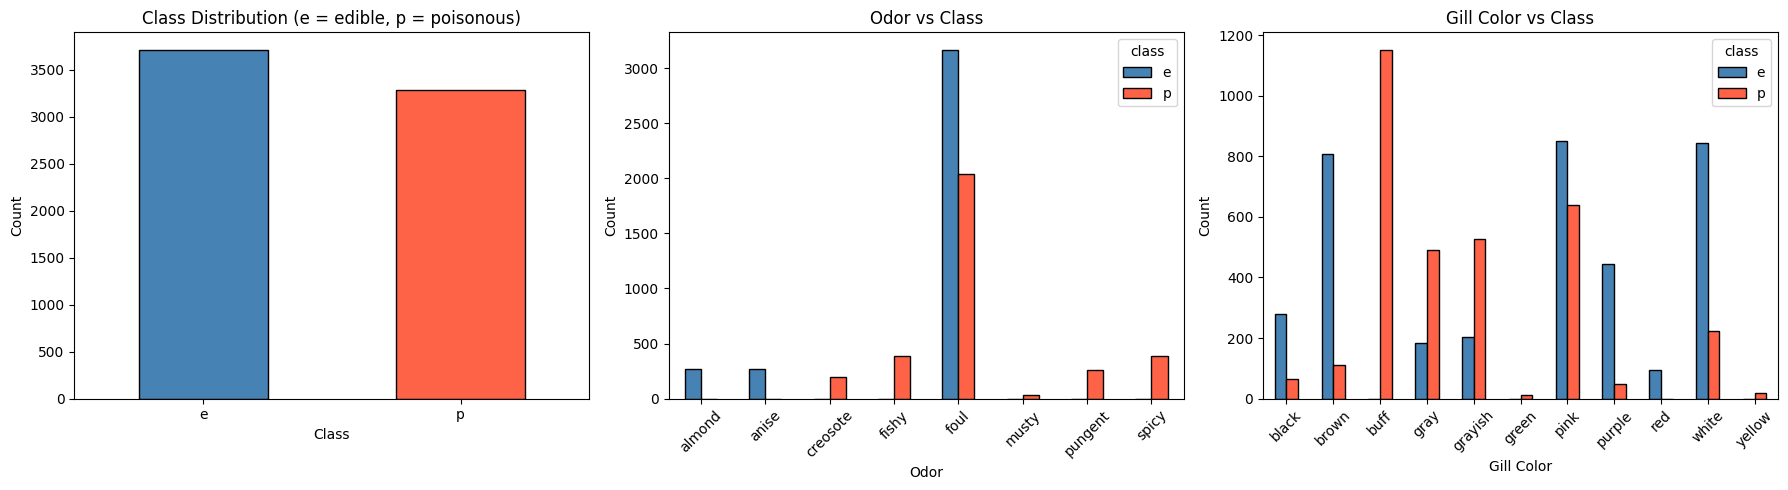


Insights:
1. Classes are roughly balanced — no severe class imbalance to address.
2. Odor is highly predictive: foul/pungent/creosote odors appear almost exclusively in poisonous mushrooms;
   almond/anise in edible ones. Odor alone could be a strong single feature.
3. Certain gill colors (e.g. buff, green) skew strongly toward one class,
   making gill-color another useful discriminator.



In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution
_ = train_df['class'].value_counts().plot(kind='bar', ax=axes[0], color=[
    'steelblue', 'tomato'], edgecolor='black')
_ = axes[0].set_title('Class Distribution (e = edible, p = poisonous)')
_ = axes[0].set_xlabel('Class')
_ = axes[0].set_ylabel('Count')
_ = axes[0].tick_params(axis='x', rotation=0)

# 2. Odor vs Class
odor_class = train_df.groupby(['odor', 'class']).size().unstack(fill_value=0)
_ = odor_class.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
_ = axes[1].set_title('Odor vs Class')
_ = axes[1].set_xlabel('Odor')
_ = axes[1].set_ylabel('Count')
_ = axes[1].tick_params(axis='x', rotation=45)

# 3. Gill color vs Class
gill_class = train_df.groupby(['gill-color', 'class']).size().unstack(fill_value=0)
_ = gill_class.plot(kind='bar', ax=axes[2], color=['steelblue', 'tomato'], edgecolor='black')
_ = axes[2].set_title('Gill Color vs Class')
_ = axes[2].set_xlabel('Gill Color')
_ = axes[2].set_ylabel('Count')
_ = axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("""
Insights:
1. Classes are roughly balanced — no severe class imbalance to address.
2. Odor is highly predictive: foul/pungent/creosote odors appear almost exclusively in poisonous mushrooms;
   almond/anise in edible ones. Odor alone could be a strong single feature.
3. Certain gill colors (e.g. buff, green) skew strongly toward one class,
   making gill-color another useful discriminator.
""")

# 9 — Encoding & Scaling

In [21]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

print("""
=== Scaling & Encoding ===
Numerical   : StandardScaler
Categorical : OneHotEncoder
""")

feature_cols = [c for c in train_df.columns if c not in {'ID', 'mushroom_id', 'class'}]

X = train_df[feature_cols].copy()
y = LabelEncoder().fit_transform(train_df['class'])

X_test = test_df[[c for c in feature_cols if c in test_df.columns]].copy()

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns    :", numeric_cols)
print("Categorical columns:", categorical_cols)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                        numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),  categorical_cols),
])

X_processed = preprocessor.fit_transform(X)
X_test_processed = preprocessor.transform(X_test)

print(f"\nTrain shape : {X_processed.shape}")
print(f"Test shape  : {X_test_processed.shape}")


=== Scaling & Encoding ===
Numerical   : StandardScaler
Categorical : OneHotEncoder

Numeric columns    : ['number_of_bruises', 'ring-number']
Categorical columns: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat']

Train shape : (7000, 99)
Test shape  : (1124, 99)


# 10 — Train/Validation Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size : {X_train.shape[0]}")
print(f"Val size   : {X_val.shape[0]}")

Train size : 5600
Val size   : 1400


# 11 — Train 9 Models

In [23]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

models = {
    'Gradient Boosting':      GradientBoostingClassifier(),
    'KNN':                    KNeighborsClassifier(),
    'Decision Tree':          DecisionTreeClassifier(),
    'Logistic Regression':    LogisticRegression(max_iter=1000),
    'Random Forest':          RandomForestClassifier(),
    'SGD Classifier':         SGDClassifier(max_iter=1000, tol=1e-3),
    'Linear SVM':             LinearSVC(),
    'AdaBoost':               AdaBoostClassifier(),
    'Extra Trees':            ExtraTreesClassifier(),
    'Naive Bayes':            GaussianNB(),
    'SVM (RBF)':              SVC(),
    'Ridge Classifier':       RidgeClassifier(),
    'Dummy Classifier':       DummyClassifier(strategy='most_frequent'),
}

results = {}

for name, model in models.items():
  model.fit(X_train, y_train)
  acc = accuracy_score(y_val, model.predict(X_val))
  results[name] = {
      'model': model,
      'accuracy': acc
  }
  print(f"{name:<25} val accuracy: {acc:.4f}")

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Gradient Boosting         val accuracy: 1.0000


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


KNN                       val accuracy: 1.0000


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Decision Tree             val accuracy: 1.0000


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Logistic Regression       val accuracy: 1.0000


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Random Forest             val accuracy: 1.0000


,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


SGD Classifier            val accuracy: 1.0000


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


Linear SVM                val accuracy: 1.0000


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


AdaBoost                  val accuracy: 0.9943


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


Extra Trees               val accuracy: 1.0000


,priors,None
,var_smoothing,1e-09


Naive Bayes               val accuracy: 0.9929


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


SVM (RBF)                 val accuracy: 1.0000


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,None
,solver,'auto'
,positive,False
,random_state,None


Ridge Classifier          val accuracy: 1.0000


,strategy,'most_frequent'
,random_state,None
,constant,None


Dummy Classifier          val accuracy: 0.5300


# 12 — Hyperparameter Tuning (3 Models)

In [24]:
print("=== Hyperparameter Tuning ===\n")

# 1. Decision Tree
dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_gs.fit(X_train, y_train)
results['Decision Tree (Tuned)'] = {
    'model': dt_gs.best_estimator_,
    'accuracy': accuracy_score(y_val, dt_gs.best_estimator_.predict(X_val))
}
print(f"Decision Tree    best params : {dt_gs.best_params_}")
print(f"Decision Tree    val accuracy: {results['Decision Tree (Tuned)']['accuracy']:.4f}\n")

# 2. Random Forest
rf_params = {'n_estimators': [50, 100], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=42),
                     rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_gs.fit(X_train, y_train)
results['Random Forest (Tuned)'] = {
    'model': rf_gs.best_estimator_,
    'accuracy': accuracy_score(y_val, rf_gs.best_estimator_.predict(X_val))
}
print(f"Random Forest    best params : {rf_gs.best_params_}")
print(f"Random Forest    val accuracy: {results['Random Forest (Tuned)']['accuracy']:.4f}\n")

# 3. KNN
knn_params = {'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance']}
knn_gs = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_gs.fit(X_train, y_train)
results['KNN (Tuned)'] = {
    'model': knn_gs.best_estimator_,
    'accuracy': accuracy_score(y_val, knn_gs.best_estimator_.predict(X_val))
}
print(f"KNN              best params : {knn_gs.best_params_}")
print(f"KNN              val accuracy: {results['KNN (Tuned)']['accuracy']:.4f}")

=== Hyperparameter Tuning ===



,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


Decision Tree    best params : {'max_depth': 10, 'min_samples_split': 2}
Decision Tree    val accuracy: 1.0000



,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


Random Forest    best params : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Random Forest    val accuracy: 1.0000



,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


KNN              best params : {'n_neighbors': 3, 'weights': 'uniform'}
KNN              val accuracy: 1.0000


# 13 — Model Comparison

=== Model Performance Comparison ===
                Model  Val Accuracy
    Gradient Boosting      1.000000
                  KNN      1.000000
        Decision Tree      1.000000
  Logistic Regression      1.000000
        Random Forest      1.000000
       SGD Classifier      1.000000
           Linear SVM      1.000000
          Extra Trees      1.000000
          KNN (Tuned)      1.000000
            SVM (RBF)      1.000000
     Ridge Classifier      1.000000
Decision Tree (Tuned)      1.000000
Random Forest (Tuned)      1.000000
             AdaBoost      0.994286
          Naive Bayes      0.992857
     Dummy Classifier      0.530000


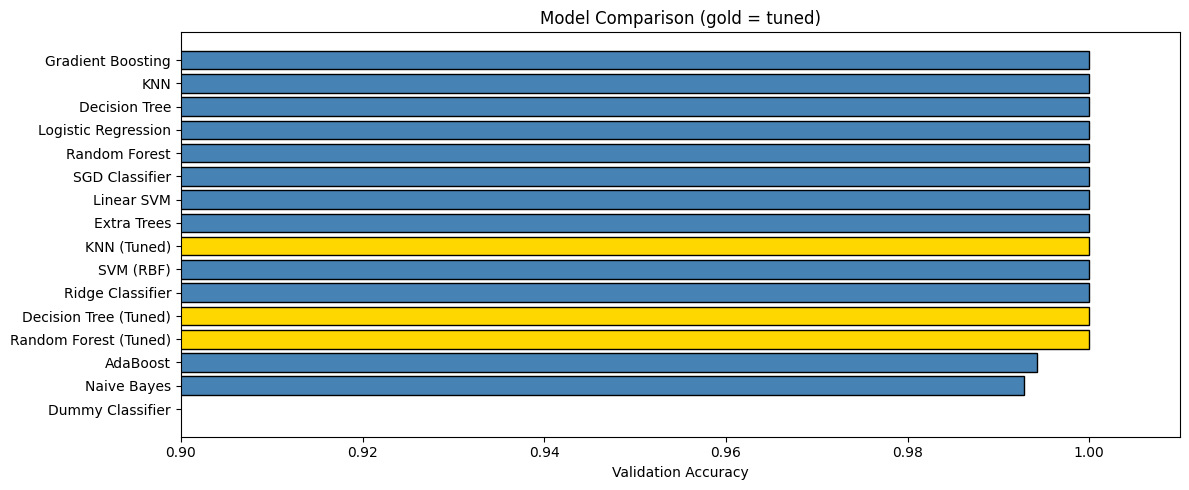

In [25]:
comparison = pd.DataFrame([
    {'Model': name, 'Val Accuracy': info['accuracy']}
    for name, info in results.items()
]).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)

print("=== Model Performance Comparison ===")
print(comparison.to_string(index=False))

_ = plt.figure(figsize=(12, 5))
colors = ['gold' if '(Tuned)' in m else 'steelblue' for m in comparison['Model']]
_ = plt.barh(comparison['Model'], comparison['Val Accuracy'], color=colors, edgecolor='black')
_ = plt.xlabel('Validation Accuracy')
_ = plt.title('Model Comparison (gold = tuned)')
_ = plt.xlim(0.9, 1.01)
_ = plt.gca().invert_yaxis()
_ = plt.tight_layout()
_ = plt.show()

# 14 — Best Model: Full Report

In [26]:
# 1. Find the maximum accuracy achieved
max_acc = comparison['Val Accuracy'].max()

# 2. Filter the comparison table for all models that hit this maximum
best_models_df = comparison[comparison['Val Accuracy'] == max_acc]

print(f"=== Models with the Best Accuracy ({max_acc:.4f}) ===")
print(best_models_df['Model'].to_string(index=False))
print("-" * 40)

# 3. Print the classification report for the first one among the best (as an example)
top_model_name = best_models_df.iloc[0]['Model']
best_model_obj = results[top_model_name]['model']

print(f"\nDetailed Report for {top_model_name}:")
print(classification_report(y_val, best_model_obj.predict(X_val),
                            target_names=['edible', 'poisonous']))

=== Models with the Best Accuracy (1.0000) ===
    Gradient Boosting
                  KNN
        Decision Tree
  Logistic Regression
        Random Forest
       SGD Classifier
           Linear SVM
          Extra Trees
          KNN (Tuned)
            SVM (RBF)
     Ridge Classifier
Decision Tree (Tuned)
Random Forest (Tuned)
----------------------------------------

Detailed Report for Gradient Boosting:
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       742
   poisonous       1.00      1.00      1.00       658

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



# 15 — Generate Submission CSV

In [27]:
final_model = GradientBoostingClassifier()
final_model.fit(X_processed, y)
test_preds = final_model.predict(X_test_processed)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [28]:
# Convert back: 1 = poisonous ('p'), 0 = edible ('e')
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'target': ['p' if p == 1 else 'e' for p in test_preds]
})

submission.to_csv('submission.csv', index=False)
print(f"submission.csv saved! Shape: {submission.shape}")
print(f"\nClass distribution:\n{submission['target'].value_counts()}")
submission.head()

submission.csv saved! Shape: (1124, 2)

Class distribution:
target
p    620
e    504
Name: count, dtype: int64


,ID,target
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e
